In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/deepfake_data')


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/deepfake_data'

In [ ]:
print(os.listdir())


['test_1_sampled.zip', 'train_1_sampled.zip', 'validation_1_sampled.zip', 'train_data', 'test_data', 'validation_data']


In [ ]:
!rm -rf train_data test_data validation_data

!unzip -q train_1_sampled.zip -d train_data
!unzip -q test_1_sampled.zip -d test_data
!unzip -q validation_1_sampled.zip -d validation_data


In [ ]:
import shutil

train_path = 'train_data'
test_path = 'test_data'
validation_path = 'validation_data'

# Create folders
for dataset_path in [train_path, test_path, validation_path]:
    os.makedirs(f"{dataset_path}/fake", exist_ok=True)
    os.makedirs(f"{dataset_path}/real", exist_ok=True)

# Function to organize images
def organize_images(dataset_path):
    for img in os.listdir(dataset_path):
        if img.endswith('.jpg'):
            src = os.path.join(dataset_path, img)
            if 'fake' in img.lower():
                dst = os.path.join(dataset_path, 'fake', img)
            else:
                dst = os.path.join(dataset_path, 'real', img)
            shutil.move(src, dst)

# Organize each dataset
organize_images(train_path)
organize_images(test_path)
organize_images(validation_path)


In [ ]:
!pip install torch torchvision transformers datasets opencv-python numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder('train_data', transform=data_transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)

print(f'Training samples: {len(train_dataset)}')
print(f'Classes: {train_dataset.classes}')


Training samples: 12485
Classes: ['fake', 'real']


In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.optim import AdamW
from tqdm import tqdm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.empty_cache()

model_name = 'google/vit-base-patch16-224-in21k'
model = ViTForImageClassification.from_pretrained(model_name, num_labels=2).to(device)
processor = ViTImageProcessor.from_pretrained(model_name)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
epochs = 3

model.train()
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    epoch_loss = 0
    for images, labels in tqdm(train_loader):
        images = processor(images, return_tensors="pt", do_rescale=False).pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f'Epoch {epoch + 1} Loss: {epoch_loss / len(train_loader)}')


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

...

Epoch 1 Loss: 0.20487988847000602
Epoch 2/3


100%|██████████| 1561/1561 [09:49<00:00,  2.65it/s]


Epoch 2 Loss: 0.05927084012835273
Epoch 3/3


100%|██████████| 1561/1561 [09:55<00:00,  2.62it/s]

Epoch 3 Loss: 0.037035420423562705


In [ ]:
validation_dataset = datasets.ImageFolder('validation_data', transform=data_transform)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=8, shuffle=False)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(validation_loader):
        images = processor(images, return_tensors="pt", do_rescale=False).pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f'Validation Accuracy: {correct / total:.2%}')


100%|██████████| 748/748 [02:27<00:00,  5.07it/s]

Validation Accuracy: 97.01%


In [ ]:
model.eval()
correct_train = 0
total_train = 0

with torch.no_grad():
    for images, labels in tqdm(train_loader):
        images = processor(images, return_tensors="pt", do_rescale=False).pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.logits.argmax(dim=1)

        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

train_accuracy = correct_train / total_train
print(f'Training Accuracy: {train_accuracy:.2%}')


100%|██████████| 1561/1561 [04:42<00:00,  5.52it/s]

Training Accuracy: 99.24%


In [ ]:
test_dataset = datasets.ImageFolder('test_data', transform=data_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f'Test samples: {len(test_dataset)}')


Test samples: 4961


In [ ]:
model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = processor(images, return_tensors="pt", do_rescale=False).pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.logits.argmax(dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())


100%|██████████| 621/621 [02:08<00:00,  4.83it/s]


Accuracy : 97.04%
Precision: 97.04%
Recall   : 97.04%
F1 Score : 97.04%

Classification Report:

              precision    recall  f1-score   support

        fake       0.97      0.97      0.97      2465
        real       0.97      0.97      0.97      2496

    accuracy                           0.97      4961
   macro avg       0.97      0.97      0.97      4961
weighted avg       0.97      0.97      0.97      4961



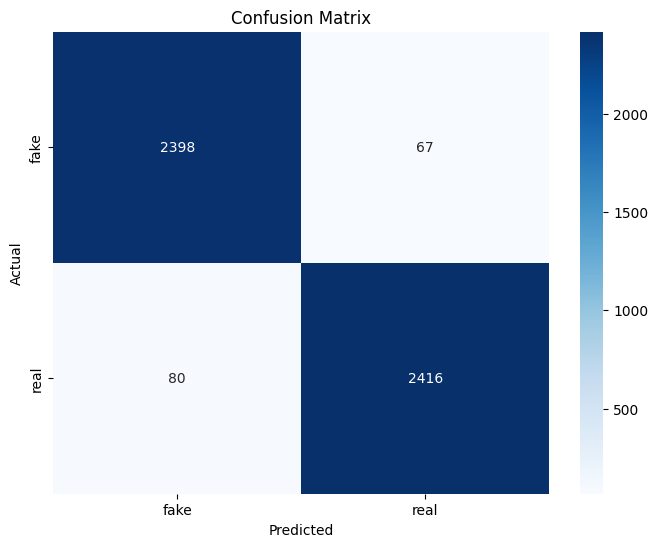

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')
f1 = f1_score(true_labels, pred_labels, average='weighted')

print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=test_dataset.classes))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/deepfake_project/vit_deepfake_model_2.0'
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print(f'Model saved to {save_path}')


Model saved to /content/drive/MyDrive/deepfake_project/vit_deepfake_model_2.0


In [ ]:
import os
os.chdir('/content/drive/MyDrive/deepfake_data')

In [ ]:
!rm -rf test_data

!unzip -q test_1_sampled.zip -d test_data


In [ ]:
import shutil

test_path = 'test_data'

# Create folders
for dataset_path in [test_path]:
    os.makedirs(f"{dataset_path}/test_1_sampled/fake", exist_ok=True)
    os.makedirs(f"{dataset_path}/test_1_sampled/real", exist_ok=True)

# Function to organize images
def organize_images(dataset_path):
    for img in os.listdir(dataset_path):
        if img.endswith('.jpg'):
            src = os.path.join(dataset_path, img)
            if 'fake' in img.lower():
                dst = os.path.join(dataset_path, 'fake', img)
            else:
                dst = os.path.join(dataset_path, 'real', img)
            shutil.move(src, dst)

# Organize each dataset
organize_images(test_path)



In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install libraries
!pip install transformers datasets scikit-learn matplotlib

# Import required packages
import torch
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define your test folder
test_folder = '/content/drive/MyDrive/deepfake_data/test_data/test_1_sampled'

# Define transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load your model from Drive
model_path = '/content/drive/MyDrive/deepfake_project/vit_deepfake_model_2.0'
model = ViTForImageClassification.from_pretrained(model_path).to(device)
processor = ViTImageProcessor.from_pretrained(model_path)

# Prepare validation dataset (adjust the folder path!)
val_folder = '/content/drive/MyDrive/deepfake_data/test_data/test_1_sampled'

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

val_dataset = datasets.ImageFolder(root=val_folder, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Evaluate model
model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        inputs = processor(images=list(images), return_tensors="pt", do_rescale=False)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)

        outputs = model(**inputs)
        preds = outputs.logits.argmax(dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(preds.cpu().numpy())

# Compute Metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')
f1 = f1_score(true_labels, pred_labels, average='weighted')

# Print metrics
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

# Plot Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,6))
plt.bar(metrics, scores, color='green')
plt.ylim(0, 1.1)
plt.title('Model Performance')
plt.ylabel('Score')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: Found no valid file for the classes fake, real. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os
from PIL import Image
import torch
from torchvision import transforms
from tqdm import tqdm

# Define your test folder
test_folder = '/content/drive/MyDrive/deepfake_data/test_data/test_1_sampled'

# Define transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load your trained model
model_path = '/content/drive/MyDrive/deepfake_project/vit_deepfake_model_2.0'
model = ViTForImageClassification.from_pretrained(model_path).to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# List of image file paths
test_images = [os.path.join(test_folder, img) for img in os.listdir(test_folder) if img.endswith('.jpg')]

# Initialize predictions
predictions = []

for img_path in tqdm(test_images):
    image = Image.open(img_path).convert('RGB')
    image = test_transform(image).unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs.logits, 1)
        predictions.append(predicted.item())

# Output prediction labels
print(predictions)


100%|██████████| 4961/4961 [02:21<00:00, 34.95it/s]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 